In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
a = 7
b = 8
n_points = 30 + a
rotation_angle = 15 * b
noise_std = 0.01 * a

print("Points per class:", n_points)
print("Rotation angle:", rotation_angle, "degrees")
print("Noise std:", noise_std)

Points per class: 37
Rotation angle: 120 degrees
Noise std: 0.07


In [4]:
np.random.seed(42)

class0 = np.random.randn(n_points, 2)
class0 += np.array([-2, 0])
class1 = np.random.randn(n_points, 2)
class1 += np.array([2, 0])

theta = np.radians(rotation_angle)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
class1 = class1 @ R.T

class0 += np.random.normal(0, noise_std, class0.shape)
class1 += np.random.normal(0, noise_std, class1.shape)
X = np.vstack((class0, class1))
y = np.hstack((np.zeros(n_points), np.ones(n_points)))

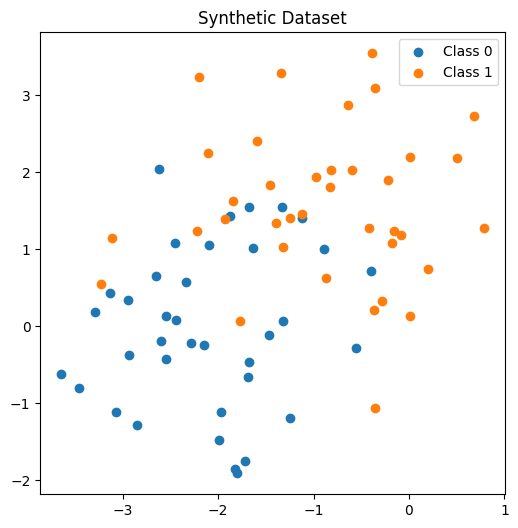

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], label="Class 0")
plt.scatter(class1[:,0], class1[:,1], label="Class 1")
plt.legend()
plt.title("Synthetic Dataset")
plt.show()

In [6]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.epochs):
            for i in range(len(X)):
                linear = np.dot(X[i], self.w) + self.b
                pred = 1 if linear >= 0 else 0
                update = self.lr * (y[i] - pred)
                self.w += update * X[i]
                self.b += update

    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        return np.where(linear >= 0, 1, 0)

In [8]:
lr = 0.01
model = Perceptron(lr=lr, epochs=100)
model.fit(X, y)
print("Weights:", model.w)
print("Bias:", model.b)

Weights: [0.00141897 0.02352626]
Bias: 0.03


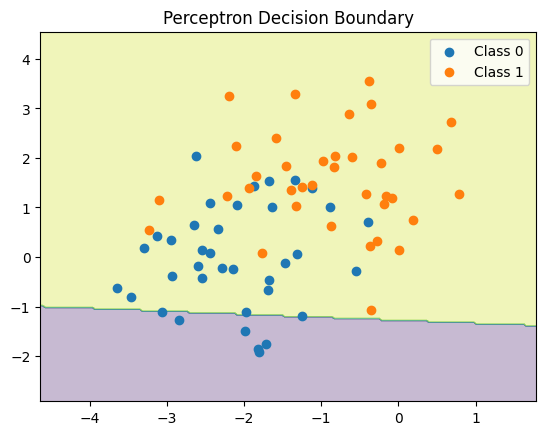

In [9]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
    plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")
    plt.legend()
    plt.title("Perceptron Decision Boundary")
    plt.show()
plot_decision_boundary(model, X, y)

In [10]:
predictions = model.predict(X)
accuracy = np.mean(predictions == y)
print("Training Accuracy:", accuracy)

Training Accuracy: 0.581081081081081


In [11]:
for lr_test in [0.001, 0.01, 0.1]:
    model_test = Perceptron(lr=lr_test, epochs=100)
    model_test.fit(X, y)
    acc = np.mean(model_test.predict(X) == y)
    print(f"Learning Rate: {lr_test} -> Accuracy: {acc}")

Learning Rate: 0.001 -> Accuracy: 0.581081081081081
Learning Rate: 0.01 -> Accuracy: 0.581081081081081
Learning Rate: 0.1 -> Accuracy: 0.581081081081081
